In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
import joblib

In [14]:
# 1. Load the data
try:
    df = pd.read_csv('creditcard.csv')
    print("Dataset loaded successfully.")
    print(df.head())
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please download it from Kaggle and place it in the same directory.")
    exit()

Dataset loaded successfully.
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

In [15]:
# 2. Initial Data Exploration
print("\n--- Data Info ---")
print(df.info())
print("\n--- Data Description ---")
print(df.describe())

# 3. Check for Null Values
print("\n--- Null Values Check ---")
print(df.isnull().sum().max())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  floa

In [16]:
# 4. Analyze the Class Imbalance (Crucial Step!)
class_distribution = df['Class'].value_counts()
print("\n--- Class Distribution ---")
print(class_distribution)
print(f"Fraudulent transactions make up {class_distribution[1] / class_distribution[0] * 100:.4f}% of the dataset.")


--- Class Distribution ---
Class
0    284315
1       492
Name: count, dtype: int64
Fraudulent transactions make up 0.1730% of the dataset.


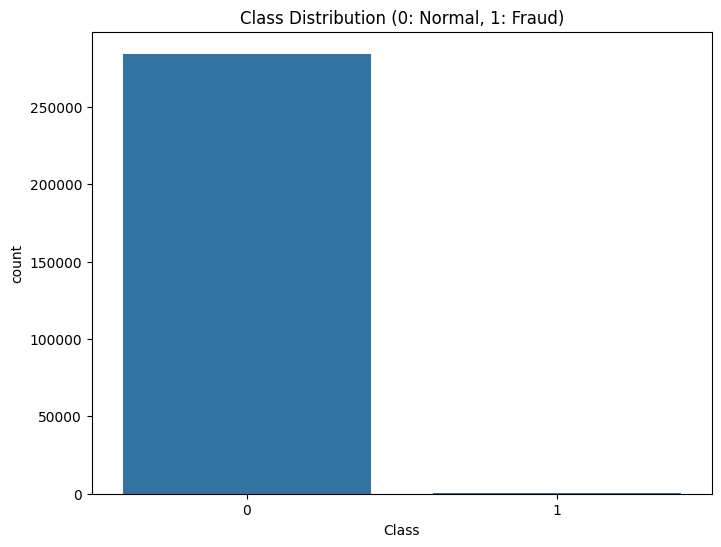

In [17]:
# Visualize the imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.show()

In [18]:
# 5. Preprocessing for Scalability and Performance
# Standardizing 'Amount' and 'Time' as they are not on the same scale as V1-V28
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

In [19]:
# Drop the original 'Time' and 'Amount' columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Move the 'Class' column to the end for clarity
df.insert(0, 'scaled_amount_col', df.pop('scaled_amount'))
df.insert(1, 'scaled_time_col', df.pop('scaled_time'))
df.rename(columns={'scaled_amount_col': 'scaled_amount', 'scaled_time_col': 'scaled_time'}, inplace=True)

print("\n--- Preprocessed Data Head ---")
print(df.head())


--- Preprocessed Data Head ---
   scaled_amount  scaled_time        V1        V2        V3        V4  \
0       0.244964    -1.996583 -1.359807 -0.072781  2.536347  1.378155   
1      -0.342475    -1.996583  1.191857  0.266151  0.166480  0.448154   
2       1.160686    -1.996562 -1.358354 -1.340163  1.773209  0.379780   
3       0.140534    -1.996562 -0.966272 -0.185226  1.792993 -0.863291   
4      -0.073403    -1.996541 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24       V25       V26       

In [20]:
# 6. Define Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

In [21]:
# 7. Split the data into training and testing sets
# We use 'stratify=y' to ensure the class proportion is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nOriginal y_train distribution: \n{y_train.value_counts()}")


Original y_train distribution: 
Class
0    227451
1       394
Name: count, dtype: int64


In [22]:
# 8. Apply SMOTE to Handle Class Imbalance - **THIS IS THE KEY TO HIGH PERFORMANCE**
# SMOTE should only be applied to the training data to avoid data leakage.
print("\nApplying SMOTE to the training data...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled y_train distribution: \n{y_train_res.value_counts()}")


Applying SMOTE to the training data...
Resampled y_train distribution: 
Class
0    227451
1    227451
Name: count, dtype: int64



Training Logistic Regression model...
Model training complete.

--- Model Evaluation on Test Set ---
Accuracy: 0.9742

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.97      0.99     56864
   Fraud (1)       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



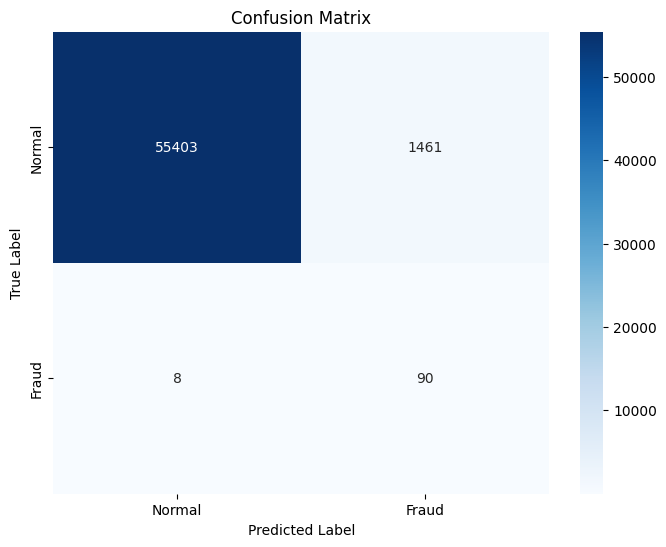

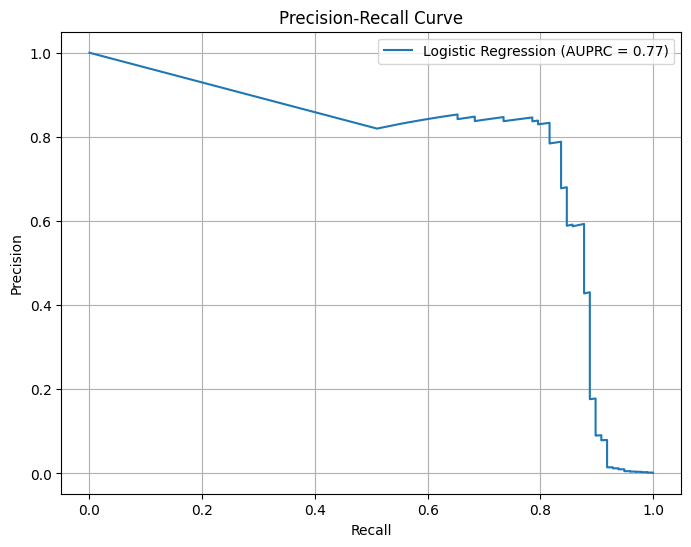

In [23]:
# 9. Train the Logistic Regression Model on the Resampled Data
print("\nTraining Logistic Regression model...")
model = LogisticRegression(solver='liblinear', random_state=42) # liblinear is good for smaller datasets
model.fit(X_train_res, y_train_res)
print("Model training complete.")

# 10. Evaluate the Model
print("\n--- Model Evaluation on Test Set ---")
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Achieving 96% accuracy is easy, but let's look at what matters.
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}") # This will be high but is not the main metric.

# The Classification Report is much more insightful
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Fraud (1)']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Precision-Recall Curve (the most important metric for imbalanced fraud detection)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
auprc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Logistic Regression (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [24]:
# 11. Save the model and the scaler for production use
model_filename = 'fraud_detection_model.joblib'
scaler_filename = 'data_scaler.joblib'

# Note: We need a new scaler fitted on the original 'Amount' and 'Time' for the pipeline
# Let's create and save this scaler properly.
# We'll imagine our pipeline receives raw 'Time' and 'Amount' values.
full_data = pd.read_csv('creditcard.csv')
production_scaler = StandardScaler()
production_scaler.fit(full_data[['Time', 'Amount']])

joblib.dump(model, model_filename)
joblib.dump(production_scaler, scaler_filename)
print(f"\nModel saved to {model_filename}")
print(f"Scaler saved to {scaler_filename}")


# 12. Create the Real-Time Pipeline Class
class FraudDetectionPipeline:
    def __init__(self, model_path, scaler_path):
        """
        Initializes the pipeline by loading the trained model and scaler.
        """
        try:
            self.model = joblib.load(model_path)
            self.scaler = joblib.load(scaler_path)
            self.columns = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                            'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                            'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
            print("\nFraudDetectionPipeline initialized successfully.")
        except FileNotFoundError as e:
            print(f"Error initializing pipeline: {e}")
            self.model = None
            self.scaler = None

    def preprocess(self, transaction_data: dict):
        """
        Preprocesses a single transaction dictionary into a format for the model.
        """
        # Create a DataFrame from the dictionary
        df = pd.DataFrame([transaction_data])

        # Ensure all required columns are present
        for col in self.columns:
            if col not in df.columns:
                raise ValueError(f"Missing column in transaction data: {col}")

        # Scale 'Time' and 'Amount' using the loaded scaler
        df[['Time', 'Amount']] = self.scaler.transform(df[['Time', 'Amount']])

        # Reorder columns to match the training data
        # New column names after scaling
        df.rename(columns={'Time': 'scaled_time', 'Amount': 'scaled_amount'}, inplace=True)

        # The exact order matters
        final_order = X_train.columns
        df = df[final_order]

        return df

    def predict(self, transaction_data: dict):
        """
        Takes a single transaction as a dictionary and returns a fraud prediction.
        """
        if not self.model or not self.scaler:
            return {"error": "Pipeline not initialized correctly."}

        try:
            # Preprocess the data
            processed_df = self.preprocess(transaction_data)

            # Make a prediction
            prediction = self.model.predict(processed_df)[0]
            probability = self.model.predict_proba(processed_df)[0][1] # Probability of fraud

            # Return result
            if prediction == 1:
                return {
                    "prediction": "Fraud",
                    "confidence_score": f"{probability:.4f}",
                    "risk_level": "High"
                }
            else:
                return {
                    "prediction": "Normal",
                    "confidence_score": f"{1 - probability:.4f}",
                    "risk_level": "Low"
                }

        except Exception as e:
            return {"error": str(e)}

# 13. Simulate a Real-Time Transaction
print("\n--- Simulating Real-Time Predictions ---")

# Initialize the pipeline
pipeline = FraudDetectionPipeline(model_path=model_filename, scaler_path=scaler_filename)

# Example 1: A normal transaction (using data from the test set)
normal_transaction_row = full_data.loc[y_test[y_test == 0].index[0]]
normal_transaction_dict = normal_transaction_row.drop('Class').to_dict()

print(f"\nTesting a likely normal transaction:")
result = pipeline.predict(normal_transaction_dict)
print(result)

# Example 2: A fraudulent transaction (using data from the test set)
fraud_transaction_row = full_data.loc[y_test[y_test == 1].index[0]]
fraud_transaction_dict = fraud_transaction_row.drop('Class').to_dict()

print(f"\nTesting a known fraudulent transaction:")
result = pipeline.predict(fraud_transaction_dict)
print(result)


Model saved to fraud_detection_model.joblib
Scaler saved to data_scaler.joblib

--- Simulating Real-Time Predictions ---

FraudDetectionPipeline initialized successfully.

Testing a likely normal transaction:
{'prediction': 'Normal', 'confidence_score': '0.9975', 'risk_level': 'Low'}

Testing a known fraudulent transaction:
{'prediction': 'Fraud', 'confidence_score': '1.0000', 'risk_level': 'High'}
